In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
sns.set_style("white")
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from PIL import Image
import nltk
from nltk.corpus import stopwords
import textblob
from textblob import TextBlob
from textblob import Word
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv
/kaggle/input/nlp-getting-started/sample_submission.csv


In [2]:
train = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
train = train.drop(["location"], axis=1)
train.head()

,id,keyword,text,target
0,1,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
train.shape

(7613, 4)

In [4]:
train.isnull().sum()

id          0
keyword    61
text        0
target      0
dtype: int64

## Preprocessing and Data Visualization

In [5]:
train['text'] = train['text'].apply(lambda x: " ".join(x.lower() for x in x.split()))
train["keyword"] = train["keyword"].str.replace('\d','')
train["keyword"] = train["keyword"].str.replace('[^\w\s]','')
keyword = pd.unique(train.keyword)[1:]

In [6]:
keys = []
for text in train.text:
    t_k = []
    for key in keyword:
        if text.find(str(key)) != -1:
            t_k.append(key)
        else:
            continue
    keys.append(t_k)
train["keyword"] = keys

In [7]:
df = train.copy()

In [8]:
#capitalization conversion
df['text'] = df['text'].apply(lambda x: " ".join(x.lower() for x in x.split()))
#punctuation
df['text'] = df['text'].str.replace('[^\w\s]','')
df['keyword'] = df['keyword'].apply(lambda x: str(x))
df["keyword"] = df["keyword"].str.replace('[^\w\s]','')
#numbers
df['text'] = df['text'].str.replace('\d','')
df["keyword"] = df["keyword"].str.replace('\d','')
#stopwords
import nltk
#nltk.download('stopwords')
from nltk.corpus import stopwords
sw = stopwords.words('english')
df['text'] = df['text'].apply(lambda x: " ".join(x for x in x.split() if x not in sw))
del_word = pd.Series(' '.join(df['text']).split()).value_counts()[1500:]
#erasure sparse
df['text'] = df['text'].apply(lambda x: " ".join(x for x in x.split() if x not in del_word))
#lemmi
from textblob import Word
#nltk.download('wordnet')
df['text'] = df['text'].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()])) 

In [9]:
features = keyword
counts = []

for i in features:    
    counts.append(df["text"].apply(lambda x: len([x for x in x.split() if x.startswith(i)])).sum())

df_fre = pd.DataFrame(columns=["names", "frequency"])
df_fre["names"] = features
df_fre["frequency"] = counts
df_fre.head()

,names,frequency
0,ablaze,28
1,accident,87
2,aftershock,19
3,airplaneaccident,0
4,ambulance,39


In [10]:
import plotly.express as px
df_class = pd.value_counts(df['target'], sort = True).sort_index()
fig = px.bar(df_class)
fig.show()

In [11]:
import plotly.express as px
fig = px.bar(df_fre, x=df_fre.names, y=df_fre.frequency,  title="Frequency of Keyword")
fig.show()

In [12]:
import plotly.express as px
fig = px.pie(df_fre, values="frequency", names="names", title='Population of Keywords')
fig.update_traces(textposition='inside')
fig.update_layout(uniformtext_minsize=7, uniformtext_mode='hide')
fig.show()

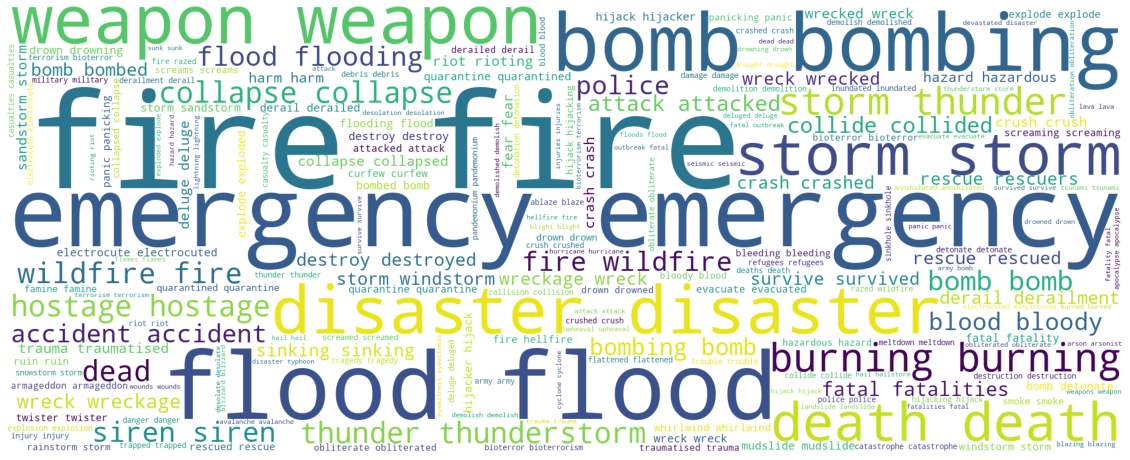

In [13]:
words  = " ".join(x for x in df.keyword)
plt.figure(figsize=(20,10))
wordcloud = WordCloud(background_color="white",  width = 2000, height = 800).generate(words)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

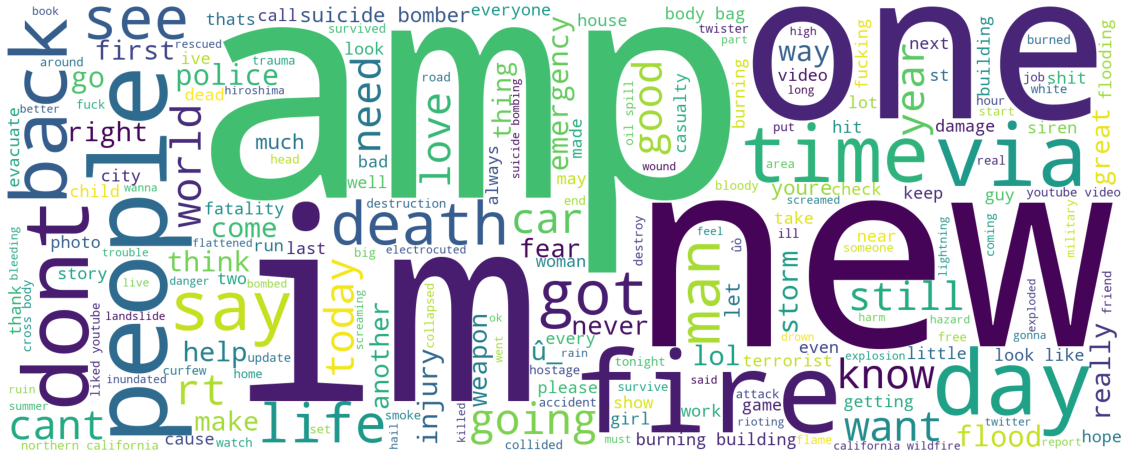

In [14]:
words  = " ".join(x for x in df.text)
plt.figure(figsize=(20,10))
wordcloud = WordCloud(background_color="white", width = 2000, height = 800).generate(words)
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

## Feature Extection

In [15]:
# Train and Test Split
from sklearn import model_selection, preprocessing
x_train, x_test, y_train, y_test = model_selection.train_test_split(df["text"], df["target"], random_state=21, test_size=0.33)

In [16]:
encoder = preprocessing.LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.fit_transform(y_test)

In [17]:
# Count
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(max_features=500)
vectorizer.fit(x_train)
x_train_count = vectorizer.transform(x_train)
x_test_count = vectorizer.transform(x_test)

In [18]:
## TF- IDF
from sklearn.feature_extraction.text import  TfidfVectorizer
tf_idf_vectorizer = TfidfVectorizer(max_features=500)
tf_idf_vectorizer.fit(x_train)
x_train_tf_idf = tf_idf_vectorizer.transform(x_train)
x_test_tf_idf = tf_idf_vectorizer.transform(x_test)

## Models

In [19]:
models_results = []
model_names = []

In [20]:
from sklearn import linear_model
from sklearn.model_selection import cross_val_score
log_reg = linear_model.LogisticRegression()
log_model = log_reg.fit(x_train_count, y_train)
acc = model_selection.cross_val_score(
    log_model,
    x_test_count,
    y_test,
    cv=7).mean()

model_names.append("Logistic Regression | Count Vectorizer")
models_results.append(acc)
print("Accuracy Count:", acc, "\n\n\n")

y_pred = log_model.predict(x_test_count)
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, y_pred))

Accuracy Count: 0.7572622363708714 



                   pre       rec       spe        f1       geo       iba       sup

          0       0.79      0.87      0.69      0.82      0.77      0.61      1439
          1       0.79      0.69      0.87      0.74      0.77      0.58      1074

avg / total       0.79      0.79      0.76      0.79      0.77      0.60      2513



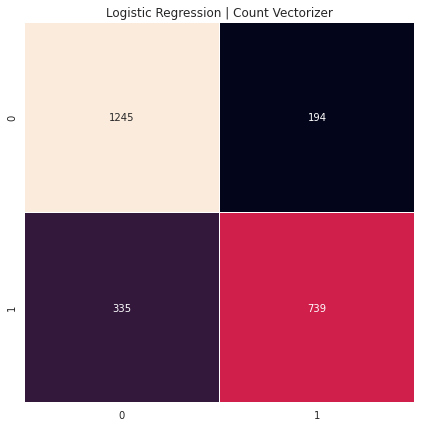

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,7))
plt.title("Logistic Regression | Count Vectorizer")
sns.heatmap(cm, annot=True, fmt="d", linewidths=0.7 ,cbar=False)
plt.show()

In [22]:
from sklearn import linear_model
from sklearn.model_selection import cross_val_score
log_reg = linear_model.LogisticRegression()
log_model = log_reg.fit(x_train_tf_idf, y_train)
acc = model_selection.cross_val_score(
    log_model,
    x_test_tf_idf,
    y_test,
    cv=7).mean()

model_names.append("Logistic Regression | TF-IDF")
models_results.append(acc)
print("Accuracy TF-IDF:", acc, "\n\n\n")

y_pred = log_model.predict(x_test_tf_idf)
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, y_pred))

Accuracy TF-IDF: 0.7604456824512535 



                   pre       rec       spe        f1       geo       iba       sup

          0       0.79      0.86      0.69      0.82      0.77      0.60      1439
          1       0.78      0.69      0.86      0.74      0.77      0.58      1074

avg / total       0.79      0.79      0.76      0.78      0.77      0.59      2513



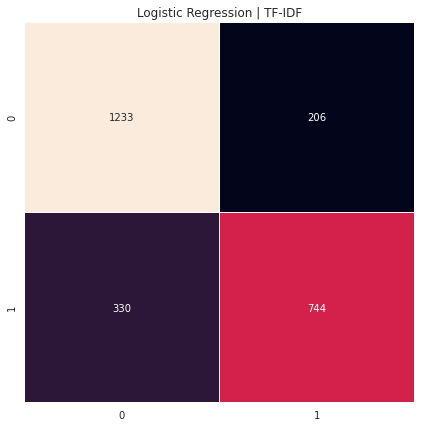

In [23]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,7))
plt.title("Logistic Regression | TF-IDF")
sns.heatmap(cm, annot=True, fmt="d", linewidths=0.7 ,cbar=False)
plt.show()

In [24]:
from sklearn import naive_bayes
nb = naive_bayes.MultinomialNB()
nb_model  = nb.fit(x_train_count, y_train)
acc = model_selection.cross_val_score(
    nb_model,
    x_test_count,
    y_test,
    cv=7).mean()

model_names.append("Naive Bayes | Count Vectorizer")
models_results.append(acc)
print("Accuracy Count:", acc, "\n\n\n")

y_pred = nb_model.predict(x_test_count)
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, y_pred))

Accuracy Count: 0.7552725825706327 



                   pre       rec       spe        f1       geo       iba       sup

          0       0.78      0.83      0.69      0.80      0.76      0.58      1439
          1       0.75      0.69      0.83      0.72      0.76      0.56      1074

avg / total       0.77      0.77      0.75      0.77      0.76      0.57      2513



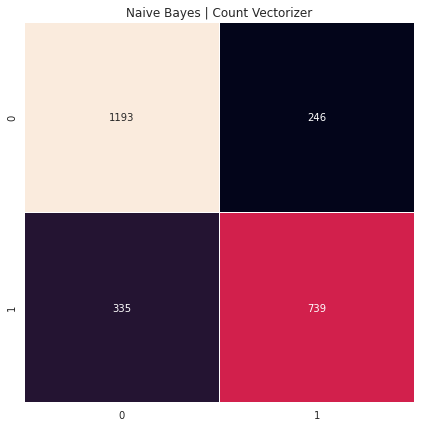

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,7))
plt.title("Naive Bayes | Count Vectorizer")
sns.heatmap(cm, annot=True, fmt="d", linewidths=0.7 ,cbar=False)
plt.show()

In [26]:
from sklearn import naive_bayes
nb = naive_bayes.MultinomialNB()
nb_model  = nb.fit(x_train_tf_idf, y_train)
acc = model_selection.cross_val_score(
    nb_model,
    x_test_tf_idf,
    y_test,
    cv=7).mean()

model_names.append("Naive Bayes | TF-IDF")
models_results.append(acc)
print("Accuracy TF-IDF:", acc, "\n\n\n")

y_pred = log_model.predict(x_test_tf_idf)
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, y_pred))

Accuracy TF-IDF: 0.7524870672502985 



                   pre       rec       spe        f1       geo       iba       sup

          0       0.79      0.86      0.69      0.82      0.77      0.60      1439
          1       0.78      0.69      0.86      0.74      0.77      0.58      1074

avg / total       0.79      0.79      0.76      0.78      0.77      0.59      2513



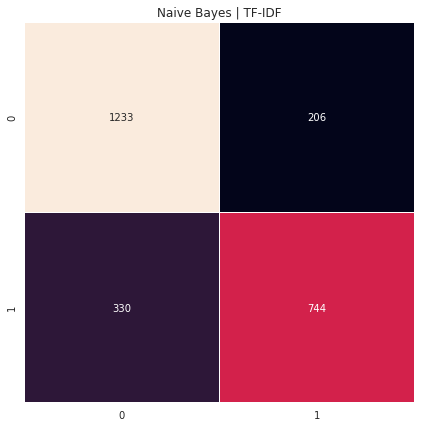

In [27]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,7))
plt.title("Naive Bayes | TF-IDF")
sns.heatmap(cm, annot=True, fmt="d", linewidths=0.7 ,cbar=False)
plt.show()

In [28]:
from sklearn import ensemble
rf = ensemble.RandomForestClassifier()
rf_model = rf.fit(x_train_count, y_train)
acc = model_selection.cross_val_score(
    rf_model,
    x_test_count,
    y_test,
    cv=7).mean()

model_names.append("Random Forest | Count Vectorizer")
models_results.append(acc)
print("Accuracy Count:", acc, "\n\n\n")

y_pred = nb_model.predict(x_test_count)
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, y_pred))

Accuracy Count: 0.7333863907680064 



                   pre       rec       spe        f1       geo       iba       sup

          0       0.79      0.84      0.70      0.81      0.77      0.59      1439
          1       0.76      0.70      0.84      0.73      0.77      0.58      1074

avg / total       0.78      0.78      0.76      0.78      0.77      0.59      2513



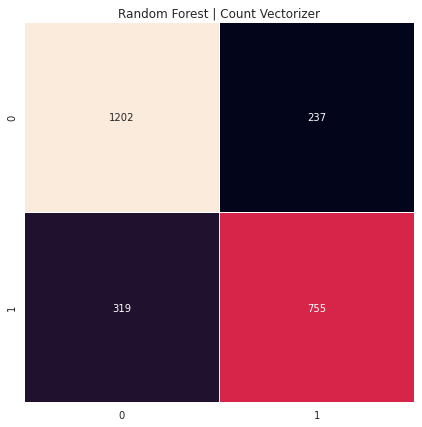

In [29]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,7))
plt.title("Random Forest | Count Vectorizer")
sns.heatmap(cm, annot=True, fmt="d", linewidths=0.7 ,cbar=False)
plt.show()

In [30]:
from sklearn import ensemble
rf = ensemble.RandomForestClassifier()
rf_model = rf.fit(x_train_tf_idf, y_train)
acc = model_selection.cross_val_score(
    rf_model,
    x_test_tf_idf,
    y_test,
    cv=7).mean()
model_names.append("Random Forest | TF-IDF")
models_results.append(acc)
print("Accuracy TF-IDF:", acc, "\n\n\n")

y_pred = log_model.predict(x_test_tf_idf)
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, y_pred))


Accuracy TF-IDF: 0.7497015519299641 



                   pre       rec       spe        f1       geo       iba       sup

          0       0.79      0.86      0.69      0.82      0.77      0.60      1439
          1       0.78      0.69      0.86      0.74      0.77      0.58      1074

avg / total       0.79      0.79      0.76      0.78      0.77      0.59      2513



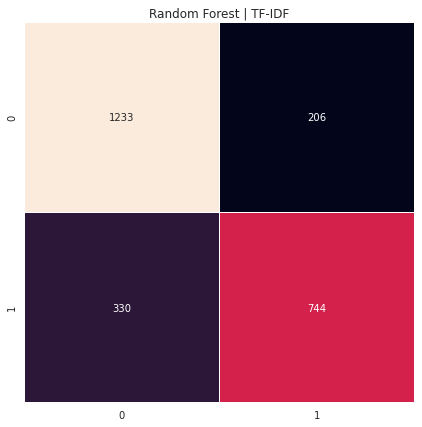

In [31]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,7))
plt.title("Random Forest | TF-IDF")
sns.heatmap(cm, annot=True, fmt="d", linewidths=0.7 ,cbar=False)
plt.show()

In [32]:
import xgboost
xgb = xgboost.XGBClassifier()
xgb_model = xgb.fit(x_train_count, y_train)
acc = model_selection.cross_val_score(
    xgb_model,
    x_test_count,
    y_test,
    cv=7).mean()

model_names.append("XGBoost | Count Vectorizer")
models_results.append(acc)
print("Accuracy Count:", acc, "\n\n\n")

y_pred = nb_model.predict(x_test_count)
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, y_pred))

Accuracy Count: 0.7536808595304417 



                   pre       rec       spe        f1       geo       iba       sup

          0       0.79      0.84      0.70      0.81      0.77      0.59      1439
          1       0.76      0.70      0.84      0.73      0.77      0.58      1074

avg / total       0.78      0.78      0.76      0.78      0.77      0.59      2513



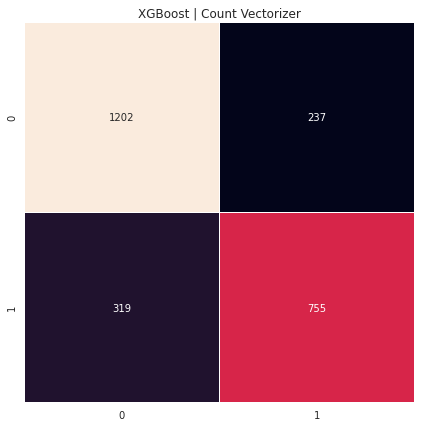

In [33]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,7))
plt.title("XGBoost | Count Vectorizer")
sns.heatmap(cm, annot=True, fmt="d", linewidths=0.7 ,cbar=False)
plt.show()

In [34]:
import xgboost
xgb = xgboost.XGBClassifier()
xgb_model = xgb.fit(x_train_tf_idf, y_train)
acc = model_selection.cross_val_score(
    xgb_model,
    x_test_tf_idf,
    y_test,
    cv=7).mean()
model_names.append("XGBoost | TF-IDF")
models_results.append(acc)
print("Accuracy TF-IDF:", acc, "\n\n\n")

y_pred = log_model.predict(x_test_tf_idf)
from imblearn.metrics import classification_report_imbalanced
print(classification_report_imbalanced(y_test, y_pred))

Accuracy TF-IDF: 0.7405491444488659 



                   pre       rec       spe        f1       geo       iba       sup

          0       0.79      0.86      0.69      0.82      0.77      0.60      1439
          1       0.78      0.69      0.86      0.74      0.77      0.58      1074

avg / total       0.79      0.79      0.76      0.78      0.77      0.59      2513



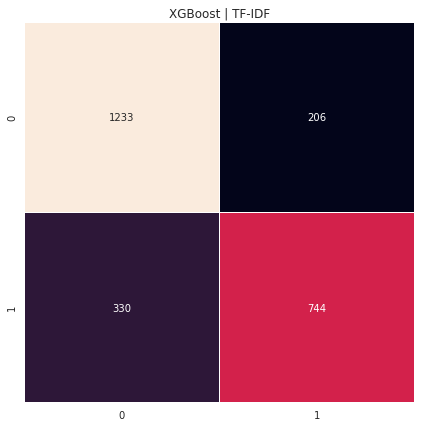

In [35]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,7))
plt.title("XGBoost | TF-IDF")
sns.heatmap(cm, annot=True, fmt="d", linewidths=0.7 ,cbar=False)
plt.show()

In [36]:
type(models_results)

list

In [37]:
models_df = pd.DataFrame(columns=["Models", "Accuracy"])
models_df["Models"] = model_names
models_df["Accuracy"] = [x*100 for x in models_results] 
models_df.head(10)

,Models,Accuracy
0,Logistic Regression | Count Vectorizer,75.726224
1,Logistic Regression | TF-IDF,76.044568
2,Naive Bayes | Count Vectorizer,75.527258
3,Naive Bayes | TF-IDF,75.248707
4,Random Forest | Count Vectorizer,73.338639
5,Random Forest | TF-IDF,74.970155
6,XGBoost | Count Vectorizer,75.368086
7,XGBoost | TF-IDF,74.054914


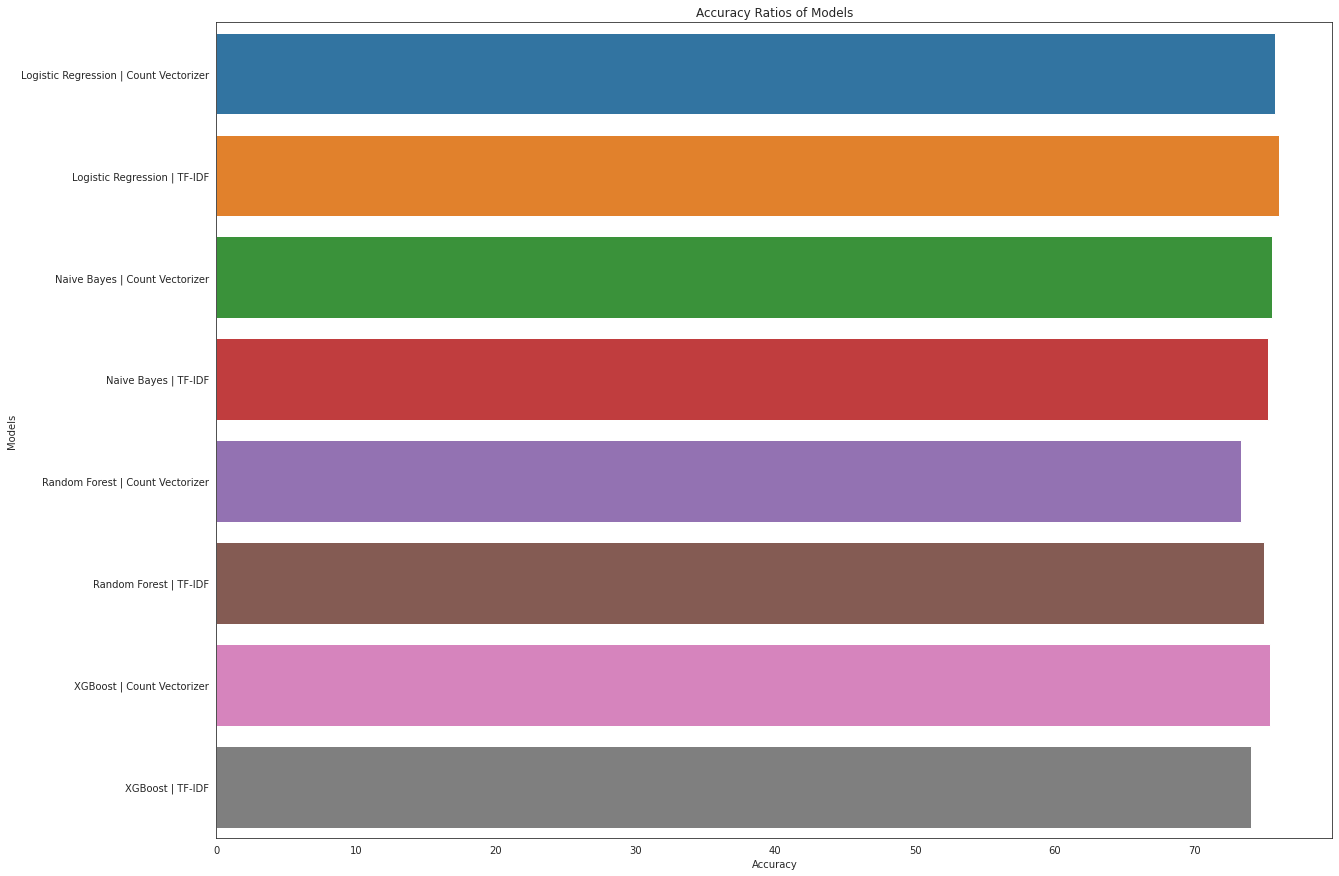

In [38]:
plt.figure(figsize=(20,15))
sns.barplot(x='Accuracy', y='Models', data=models_df)
plt.xlabel('Accuracy')
plt.title('Accuracy Ratios of Models');

In [39]:
test = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv")
test = test.drop(["keyword", "location"], axis=1)
test.head()

,id,text
0,0,Just happened a terrible car crash
1,2,"Heard about #earthquake is different cities, s..."
2,3,"there is a forest fire at spot pond, geese are..."
3,9,Apocalypse lighting. #Spokane #wildfires
4,11,Typhoon Soudelor kills 28 in China and Taiwan


In [40]:
#capitalization conversion
test['text'] = test['text'].apply(lambda x: " ".join(x.lower() for x in x.split()))
#punctuation
test['text'] = test['text'].str.replace('[^\w\s]','')
#numbers
test['text'] = test['text'].str.replace('\d','')
#stopwords
import nltk
#nltk.download('stopwords')
from nltk.corpus import stopwords
sw = stopwords.words('english')
test['text'] = test['text'].apply(lambda x: " ".join(x for x in x.split() if x not in sw))
del_word = pd.Series(' '.join(test['text']).split()).value_counts()[7000:]
#erasure sparse
test['text'] = test['text'].apply(lambda x: " ".join(x for x in x.split() if x not in del_word))
#lemmi
from textblob import Word
#nltk.download('wordnet')
test['text'] = test['text'].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()])) 

In [41]:
data_test = tf_idf_vectorizer.transform(test.text)

In [42]:
submission = pd.read_csv("/kaggle/input/nlp-getting-started/sample_submission.csv")
submission.head()

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0


In [43]:
submission = test.id.copy().to_frame()
submission['target'] = log_model.predict(data_test)

In [44]:
submission.to_csv("submission.csv", index=False)